First 5 rows:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  BIAS_COL  
0  396.90   4.98  24.0         1  
1  396.90   9.14  21.6         1  
2  392.83   4.03  34.7         1  
3  394.63   2.94  33.4         1  
4  396.90   5.33  36.2         1  

Missing Values:
 CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
BIAS_COL    0
dtype: int64

Summary:
              CRIM          ZN       INDUS 

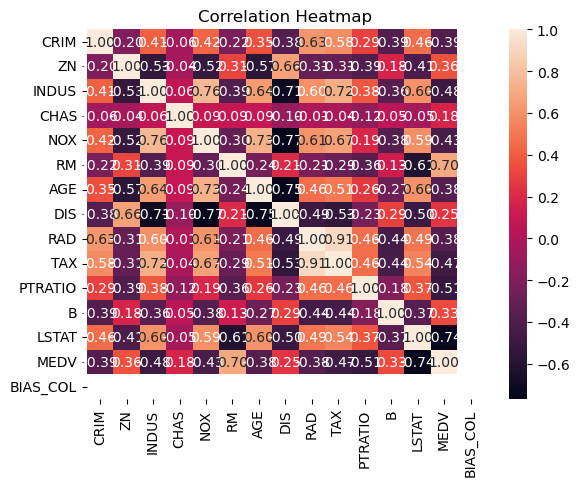

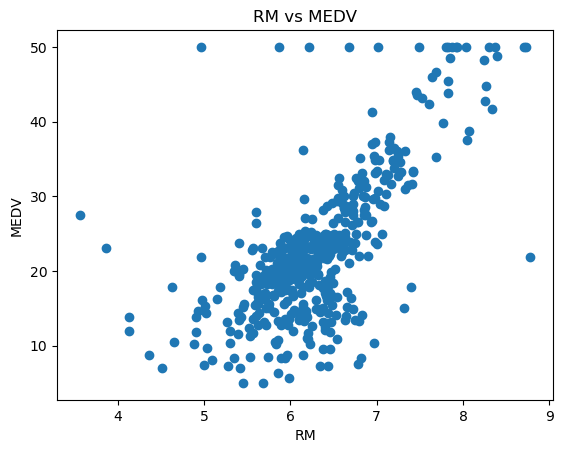

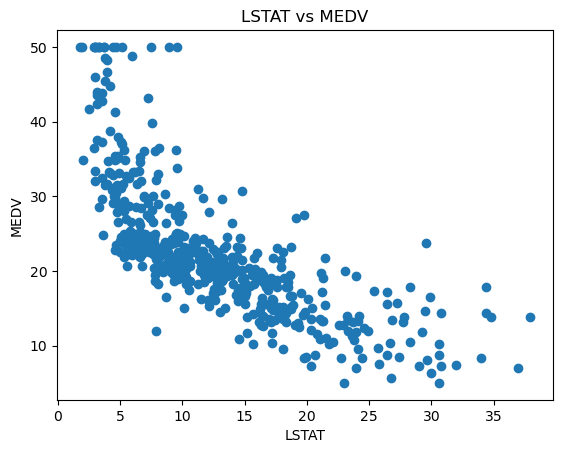

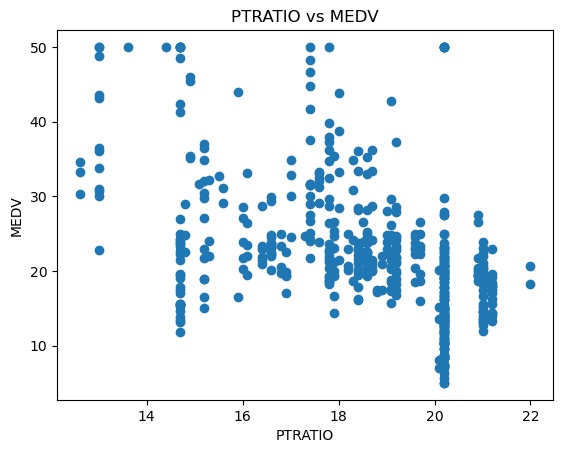

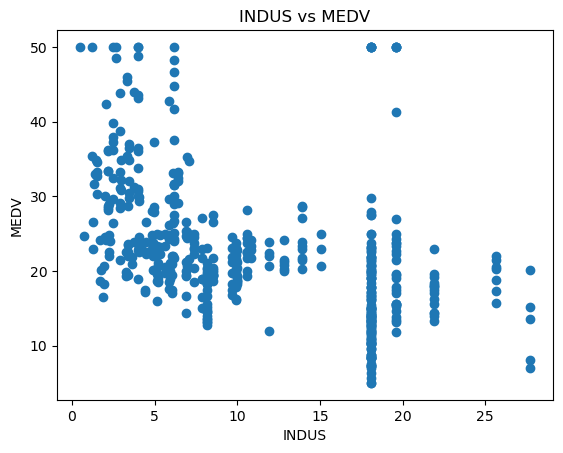

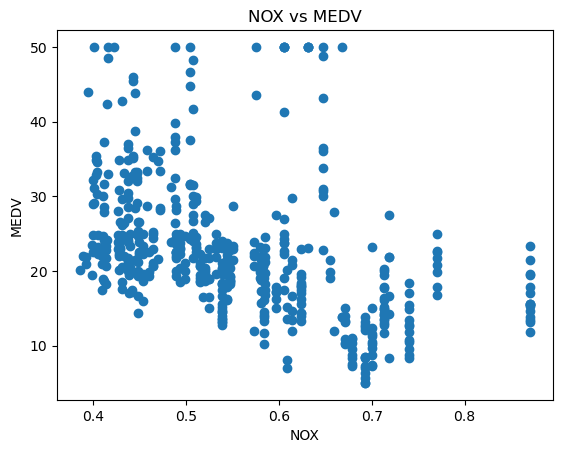

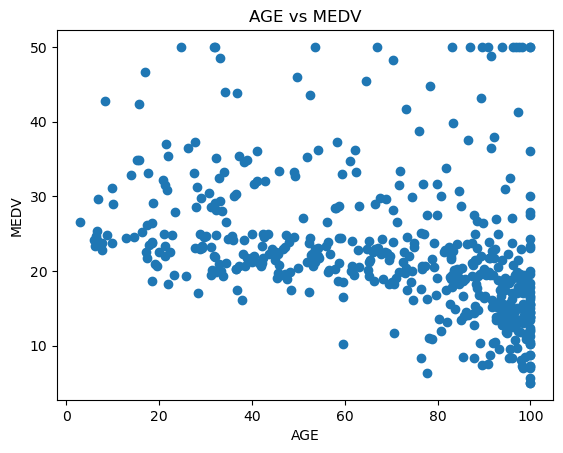

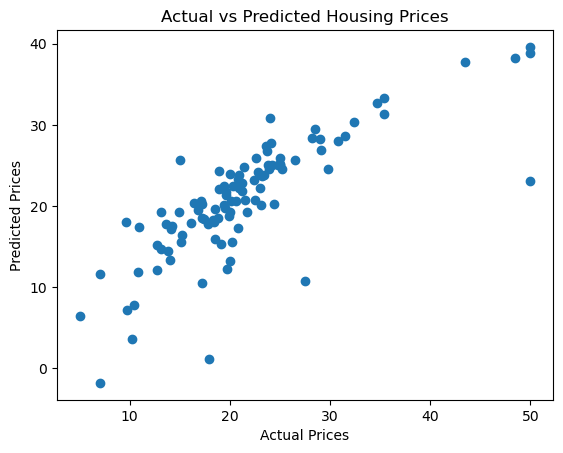

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 2. Load Dataset (UPDATE PATH)
df = pd.read_csv(r"Boston.csv")

# 🔹 3. Clean Column Names (important)
df.columns = df.columns.str.strip()

print("First 5 rows:\n", df.head())

# 🔹 4. Data Exploration
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

# 🔹 5. Select Features and Target
features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'AGE']
target = 'MEDV'

X = df[features]
y = df[target]

# 🔹 6. Handle Missing Values (if any)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# 🔹 7. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 8. Build Model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 9. Predictions
y_pred = model.predict(X_test)

# 🔹 10. Evaluation
print("\nModel Performance:")
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# 🔹 11. Feature Importance (Coefficients)
print("\nFeature Coefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef}")

# 🔹 12. Correlation Heatmap
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 🔹 13. Scatter Plots
for col in features:
    plt.figure()
    plt.scatter(df[col], df[target])
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs MEDV")
    plt.show()

# 🔹 14. Actual vs Predicted Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()